In [70]:
# !pip install kagglehub

import os, random, numpy as np, pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything()

print("Device:", DEVICE)

Device: cuda


In [71]:
import kagglehub

root = kagglehub.dataset_download("abhishekbuddiga06/embryo-dataset")

DATA_DIR = os.path.join(root, "embryo_dataset", "embryo_dataset")
ANN_DIR  = os.path.join(root, "embryo_dataset_annotations", "embryo_dataset_annotations")

print("Dataset Ready")

Dataset Ready


In [72]:
VIDEO_SAMPLE_FRAC = 1.0
VIDEO_SAMPLE_SEED = 42

SEQ_LEN    = 8
SEQ_STRIDE = 4

IMG_SIZE   = 112
CROP_SIZE  = 112

BATCH_SIZE   = 16
NUM_EPOCHS   = 12
LR           = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 2

PATIENCE     = 4

LSTM_HIDDEN   = 256
LSTM_LAYERS   = 2
LSTM_DROPOUT  = 0.3

FREEZE_UP_TO  = 10   # freeze first few layers

NUM_CLASSES   = 16

LAMBDA_ORD = 0.1
GAMMA      = 2.0

PHASES = ['tPB2','tPNa','tPNf','t2','t3','t4','t5','t6',
          't7','t8','t9+','tM','tSB','tB','tEB','tHB']

label_map = {p: i for i, p in enumerate(PHASES)}

print("Config Loaded ")

Config Loaded 


In [73]:
def build_dataframe():

    rows = []

    for file in tqdm(os.listdir(ANN_DIR)):

        if not file.endswith(".csv"):
            continue

        emb = file.replace("_phases.csv","")
        f0_path = os.path.join(DATA_DIR, emb, "F0")

        if not os.path.exists(f0_path):
            continue

        images = sorted([
            f for f in os.listdir(f0_path)
            if f.endswith((".png",".jpg",".jpeg"))
        ])

        ann = pd.read_csv(os.path.join(ANN_DIR,file), header=None)
        ann.columns = ["phase","start","end"]

        for _, r in ann.iterrows():

            if r["phase"] not in label_map:
                continue

            label = label_map[r["phase"]]

            for i in range(int(r["start"]), int(r["end"])):

                if i < len(images):
                    rows.append([
                        os.path.join(f0_path, images[i]),
                        label,
                        emb,
                        i
                    ])

    df = pd.DataFrame(rows, columns=["path","label","emb","frame"])
    return df.sort_values(["emb","frame"]).reset_index(drop=True)

In [74]:
df = build_dataframe()

print("Total Frames:", len(df))
print("Total Embryos:", df["emb"].nunique())

100%|██████████| 704/704 [00:01<00:00, 426.43it/s]


Total Frames: 84670
Total Embryos: 211


In [75]:
rng = np.random.RandomState(VIDEO_SAMPLE_SEED)

embryos = df["emb"].unique()

if VIDEO_SAMPLE_FRAC < 1.0:
    embryos = rng.choice(
        embryos,
        int(len(embryos) * VIDEO_SAMPLE_FRAC),
        replace=False
    )

df = df[df.emb.isin(embryos)]
train_ids, temp_ids = train_test_split(embryos, test_size=0.3, random_state=42)
val_ids, test_ids   = train_test_split(temp_ids, test_size=0.5, random_state=42)

train_df = df[df.emb.isin(train_ids)]
val_df   = df[df.emb.isin(val_ids)]
test_df  = df[df.emb.isin(test_ids)]
print("Split sizes:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Split sizes:
Train: 59057
Val: 12003
Test: 13610


In [76]:
def make_sequences(df):

    seqs = []

    for _, group in df.groupby("emb"):

        group = group.sort_values("frame")

        paths  = group["path"].tolist()
        labels = group["label"].tolist()

        for i in range(0, len(paths) - SEQ_LEN, SEQ_STRIDE):

            seq = paths[i:i+SEQ_LEN]
            label = labels[i+SEQ_LEN-1]

            seqs.append((seq, label))

    return seqs

In [77]:
train_seqs = make_sequences(train_df)
val_seqs   = make_sequences(val_df)
test_seqs  = make_sequences(test_df)
print("Sequences:")
print("Train:", len(train_seqs))
print("Val:", len(val_seqs))
print("Test:", len(test_seqs))

Sequences:
Train: 14522
Val: 2949
Test: 3350


In [78]:
train_labels = [y for _, y in train_seqs]

unique_classes = np.unique(train_labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=train_labels
)

full_weights = np.ones(NUM_CLASSES)

for cls, w in zip(unique_classes, weights):
    full_weights[cls] = w

class_weights = torch.tensor(full_weights, dtype=torch.float32).to(DEVICE)

In [79]:
class SeqDataset(Dataset):

    def __init__(self, seqs, transform):
        self.seqs = seqs
        self.tf = transform

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):

        paths, label = self.seqs[idx]

        frames = []

        for p in paths:
            img = Image.open(p).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            img = self.tf(img)
            frames.append(img)

        return torch.stack(frames), torch.tensor(label)

In [80]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])

In [81]:
train_loader = DataLoader(SeqDataset(train_seqs,train_tf),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS)

val_loader = DataLoader(SeqDataset(val_seqs,test_tf),
                        batch_size=BATCH_SIZE,
                        num_workers=NUM_WORKERS)

test_loader = DataLoader(SeqDataset(test_seqs,test_tf),
                         batch_size=BATCH_SIZE,
                         num_workers=NUM_WORKERS)

In [82]:
class CNN_LSTM(nn.Module):

    def __init__(self):
        super().__init__()

        backbone = models.mobilenet_v2(weights="DEFAULT")

        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.feat_dim = backbone.last_channel

        for i, p in enumerate(self.cnn.parameters()):
            if i < FREEZE_UP_TO:
                p.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=self.feat_dim,
            hidden_size=LSTM_HIDDEN,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            dropout=LSTM_DROPOUT
        )

        self.fc = nn.Linear(LSTM_HIDDEN, NUM_CLASSES)

    def forward(self, x):

        B, T, C, H, W = x.shape

        x = x.view(B*T, C, H, W)

        feats = self.cnn(x)
        feats = self.pool(feats).view(B, T, self.feat_dim)

        _, (hn, _) = self.lstm(feats)

        return self.fc(hn[-1])

In [83]:
class FinalOrdinalLoss(nn.Module):

    def __init__(self, weights, num_classes):
        super().__init__()

        self.ce = nn.CrossEntropyLoss(weight=weights)
        self.num_classes = num_classes

    def forward(self, logits, targets):

        ce = self.ce(logits, targets)

        probs = torch.softmax(logits, dim=1)

        class_ids = torch.arange(self.num_classes).float().to(logits.device)

        soft_pred = torch.sum(probs * class_ids, dim=1)

        dist = torch.abs(soft_pred - targets.float())

        penalty = (dist / (self.num_classes - 1)) ** GAMMA

        return ce + LAMBDA_ORD * penalty.mean()

In [84]:
model = CNN_LSTM().to(DEVICE)

loss_fn = FinalOrdinalLoss(class_weights, NUM_CLASSES).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

In [85]:
def train_epoch():

    model.train()
    total_loss = 0

    for x,y in train_loader:

        x,y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()

        out = model(x)

        loss = loss_fn(out,y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss/len(train_loader)

In [86]:
def evaluate(loader):

    model.eval()
    preds, trues = [], []

    with torch.no_grad():

        for x,y in loader:

            x = x.to(DEVICE)

            out = model(x)

            p = torch.argmax(out,1).cpu().numpy()

            preds.extend(p)
            trues.extend(y.numpy())

    return accuracy_score(trues,preds), f1_score(trues,preds,average="weighted")

In [87]:
best_f1 = 0
patience = 0

print("\n Training CNN + LSTM\n")

for epoch in range(NUM_EPOCHS):

    loss = train_epoch()
    val_acc, val_f1 = evaluate(val_loader)

    print(f"""
Epoch {epoch+1}
Loss      : {loss:.4f}
Val Acc   : {val_acc:.4f}
Val F1    : {val_f1:.4f}
-------------------------------
""")

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience = 0
        torch.save(model.state_dict(),"best.pth")
    else:
        patience += 1

    if patience >= PATIENCE:
        print(" Early stopping")
        break


 Training CNN + LSTM


Epoch 1
Loss      : 1.9704
Val Acc   : 0.2536
Val F1    : 0.2449
-------------------------------


Epoch 2
Loss      : 1.6349
Val Acc   : 0.2506
Val F1    : 0.2433
-------------------------------


Epoch 3
Loss      : 1.4058
Val Acc   : 0.2876
Val F1    : 0.2894
-------------------------------


Epoch 4
Loss      : 1.2677
Val Acc   : 0.2723
Val F1    : 0.2709
-------------------------------


Epoch 5
Loss      : 1.1289
Val Acc   : 0.3252
Val F1    : 0.3251
-------------------------------


Epoch 6
Loss      : 1.0099
Val Acc   : 0.3337
Val F1    : 0.3419
-------------------------------


Epoch 7
Loss      : 0.9510
Val Acc   : 0.2984
Val F1    : 0.3023
-------------------------------


Epoch 8
Loss      : 0.8611
Val Acc   : 0.2848
Val F1    : 0.2829
-------------------------------


Epoch 9
Loss      : 0.8082
Val Acc   : 0.2709
Val F1    : 0.2793
-------------------------------


Epoch 10
Loss      : 0.7715
Val Acc   : 0.2825
Val F1    : 0.2816
-------------------

In [88]:
model.load_state_dict(torch.load("best.pth"))

test_acc, test_f1 = evaluate(test_loader)

print("\n FINAL RESULTS")
print(f"Accuracy : {test_acc:.4f}")
print(f"F1 Score : {test_f1:.4f}")


 FINAL RESULTS
Accuracy : 0.3125
F1 Score : 0.3157


In [94]:
def collect_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)
            preds = torch.argmax(out, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_preds)
    # Get predictions
y_val, p_val = collect_preds(model, val_loader)
y_test, p_test = collect_preds(model, test_loader)

In [96]:
from sklearn.metrics import classification_report

labels_present = sorted(np.unique(y_val))

print("Validation Report:\n")
print(classification_report(
    y_val,
    p_val,
    labels=labels_present,
    target_names=[PHASES[i] for i in labels_present]
))

print("\nTest Report:\n")
labels_present_test = sorted(np.unique(y_test))

print(classification_report(
    y_test,
    p_test,
    labels=labels_present_test,
    target_names=[PHASES[i] for i in labels_present_test]
))

Validation Report:

              precision    recall  f1-score   support

        tPB2       0.14      0.50      0.22        52
        tPNa       0.66      0.45      0.53       396
        tPNf       0.14      0.25      0.18        59
          t2       0.37      0.22      0.27       296
          t3       0.05      0.26      0.09        39
          t4       0.37      0.43      0.40       315
          t5       0.01      0.02      0.01        51
          t6       0.03      0.01      0.01       140
          t7       0.31      0.20      0.25       181
          t8       0.22      0.21      0.21       277
         t9+       0.43      0.42      0.43       448
          tM       0.31      0.36      0.34       188
         tSB       0.45      0.47      0.46       220
          tB       0.37      0.31      0.34       134
         tEB       0.38      0.37      0.38       153

    accuracy                           0.33      2949
   macro avg       0.28      0.30      0.27      2949
weight

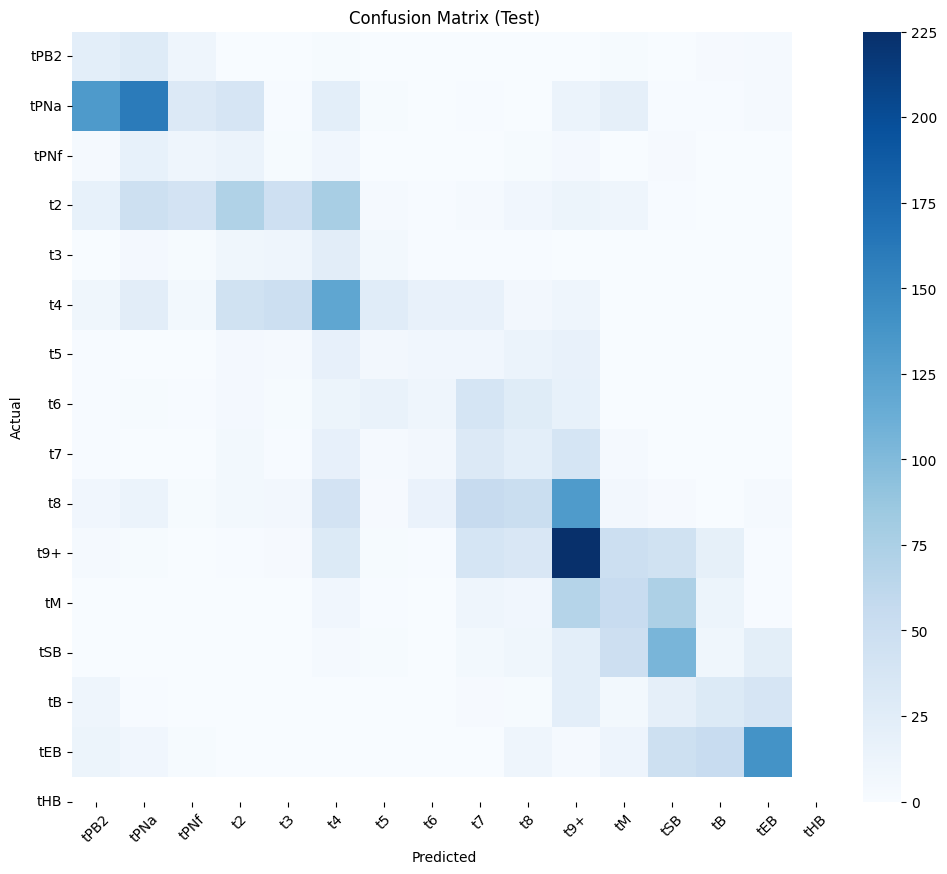

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, p_test)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues",
            xticklabels=PHASES,
            yticklabels=PHASES)

plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

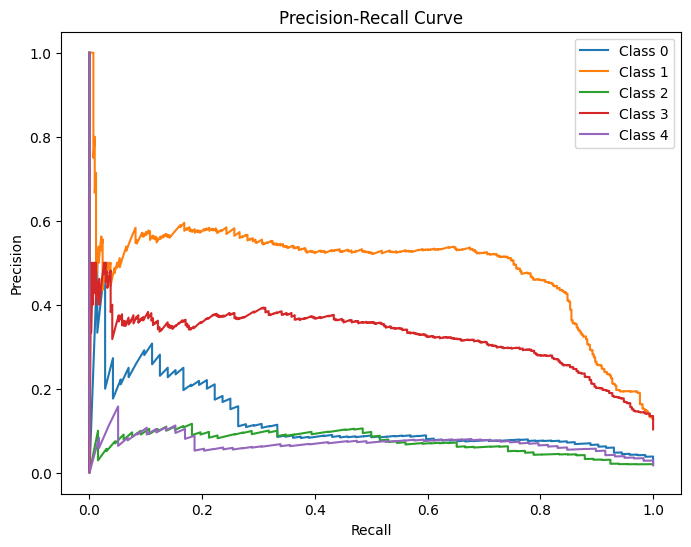

In [98]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# convert labels to one-hot
y_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))

model.eval()
probs = []

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(DEVICE)
        out = torch.softmax(model(x), dim=1).cpu().numpy()
        probs.append(out)

probs = np.vstack(probs)

# plot for a few classes (avoid clutter)
plt.figure(figsize=(8,6))

for i in range(min(5, NUM_CLASSES)):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()